# Filtros lineares

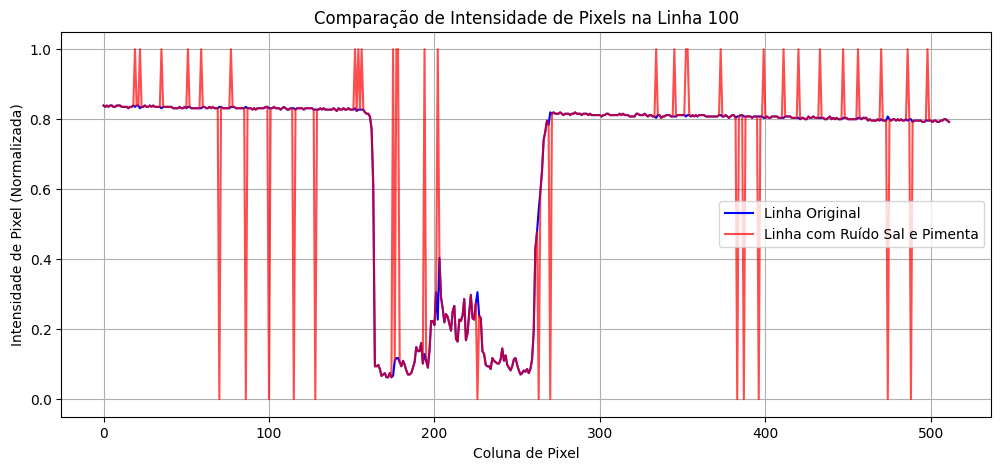

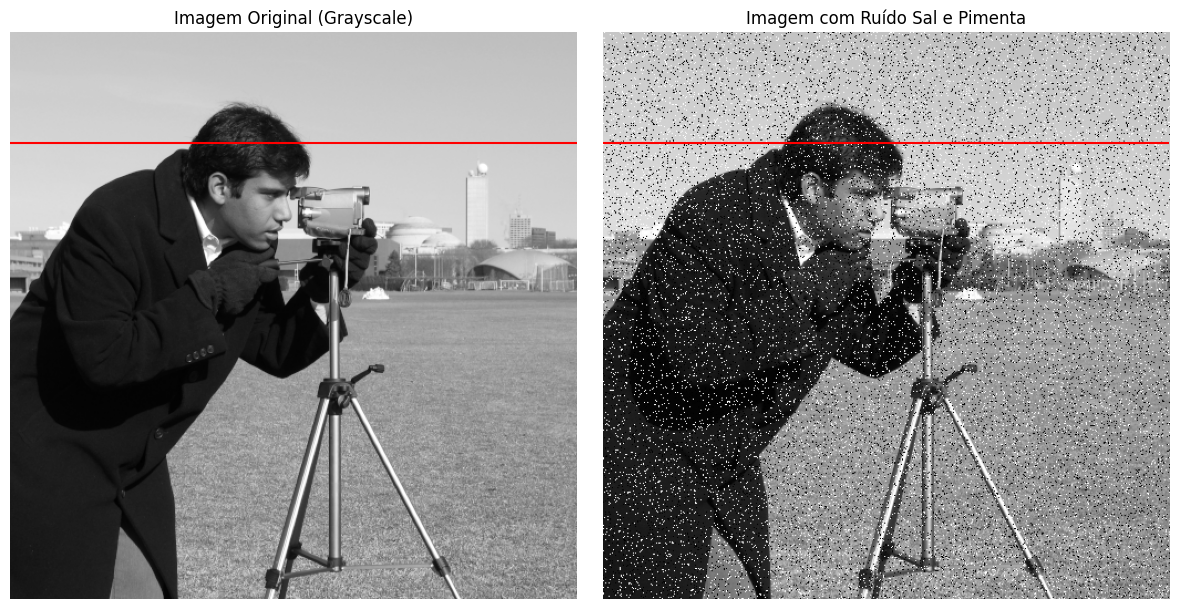

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.color import rgb2gray

# Função gera ruído do notebook anterior
def gera_ruido(original, noise_type="gaussian", noise_level=0.02):
    # Verifica se a imagem é nível de cinzas
    if len(original.shape) == 3:
        grayscale = rgb2gray(original)
    else:
        grayscale = original

    # --- Adiciona ruído gaussiano, ou sal e pimenta ---
    if noise_type == "gaussian":
        noise = np.random.normal(0, noise_level, grayscale.shape)
        grayscale_ruido = grayscale + noise
    else: # "salt_pepper"
        grayscale_ruido = grayscale.copy()
        p = noise_level  # fração de pixels afetados

        # máscaras aleatórias
        rnd = np.random.rand(*grayscale.shape)
        grayscale_ruido[rnd < p / 2] = 0      # pimenta
        grayscale_ruido[rnd > 1 - p / 2] = 1  # sal

    # Garante faixa dinâmica válida
    grayscale_ruido = np.clip(grayscale_ruido, 0, 1)
    return(grayscale_ruido)

def main():
  # Carrega uma imagem
  original_image = data.camera()

  # Normaliza para 0-1
  grayscale_original = original_image / 255.0

  # Gera ruído sal e pimenta
  noisy_image_sp = gera_ruido(grayscale_original, noise_type="salt_pepper", noise_level=0.1)

  # Vamos escolher uma linha
  row_index = 100

  # Extrai a linha das imagens com e sem ruído
  originalRow = grayscale_original[row_index, :]
  noisyRow = noisy_image_sp[row_index, :]

  # Plot the pixel intensities of the selected rows
  plt.figure(figsize=(12, 5))
  plt.plot(originalRow, label='Linha Original', color='blue')
  plt.plot(noisyRow, label='Linha com Ruído Sal e Pimenta', color='red', alpha=0.7)
  plt.title(f'Comparação de Intensidade de Pixels na Linha {row_index}')
  plt.xlabel('Coluna de Pixel')
  plt.ylabel('Intensidade de Pixel (Normalizada)')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Display the full images for context (optional)
  plt.figure(figsize=(12, 6))

  plt.subplot(1, 2, 1)
  plt.imshow(grayscale_original, cmap='gray')
  plt.axhline(y=row_index, color='r', linestyle='-') # Highlight the selected row
  plt.title('Imagem Original (Grayscale)')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(noisy_image_sp, cmap='gray')
  plt.axhline(y=row_index, color='r', linestyle='-') # Highlight the selected row
  plt.title('Imagem com Ruído Sal e Pimenta')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

main()

# Exercício: Implemente uma função que aplique o filtro da média para um kernel de 3 pontos. Sua função deve receber uma linha de uma imagem e retornar uma nova linha com o resultado do filtro da média de três pontos.

In [3]:
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

# Upload dos arquivos
uploaded = files.upload()

imagens = []

for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)

    # Converte para tons de cinza se estiver em RGB
    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas com sucesso.")


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
12 imagens carregadas com sucesso.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def filtroMedia3pontos(rowData):
    # Cria uma cópia do tipo float para guardar o resultado
    resultado = np.copy(rowData).astype(float)


    # Aplique o filtro da média usando for
    for i in range(1, len(rowData)-1):
        resultado[i] = (rowData[i-1] + rowData[i] + rowData[i+1]) / 3.0

    return resultado


# Faça uma função main que chame a função criada para cinco
# linhas arbitrárias e retorne o resultado


# Para cada linha, apresente o gráfico como no exemplo acima



Exercício: Repita o exercício para um kernel de cinco pontos.

In [6]:
def main():
    img = imagens[0]
    linhas = [50, 100, 150, 200, 250]

    for row_index in linhas:
        linha_original = img[row_index, :]
        linha_filtrada = filtroMedia3pontos(linha_original)

        plt.figure(figsize=(12,4))
        plt.plot(linha_original, label='Linha Original')
        plt.plot(linha_filtrada, label='Filtro Média 3 Pontos')
        plt.title(f'Filtro da Média (3 pontos) na linha {row_index}')
        plt.xlabel('Coluna do pixel')
        plt.ylabel('Intensidade')
        plt.legend()
        plt.grid(True)
        plt.show()


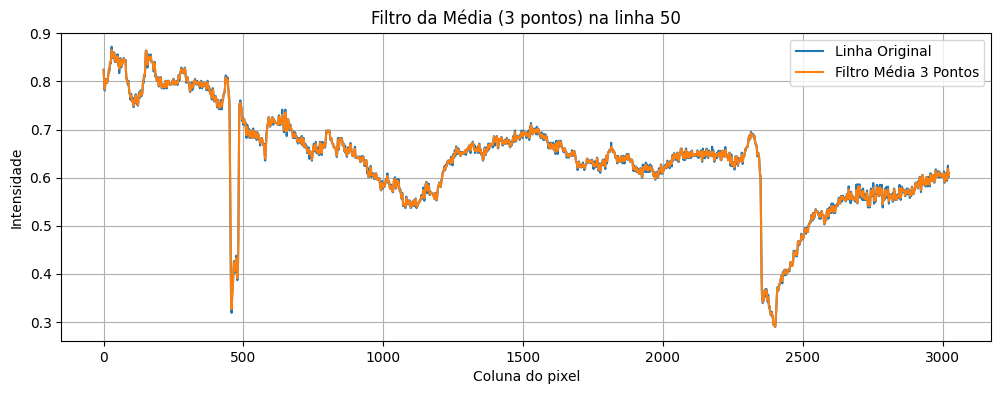

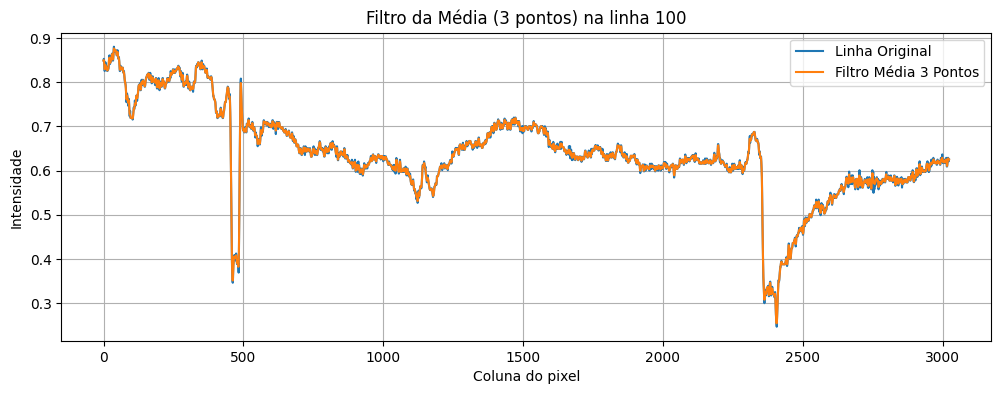

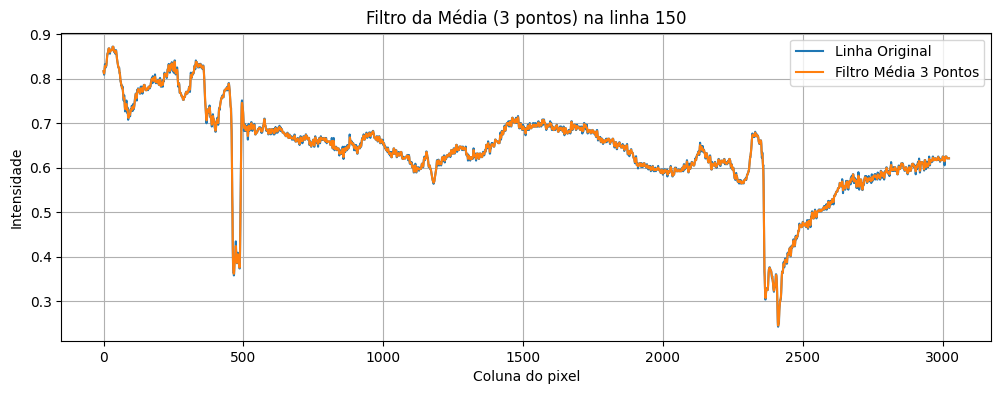

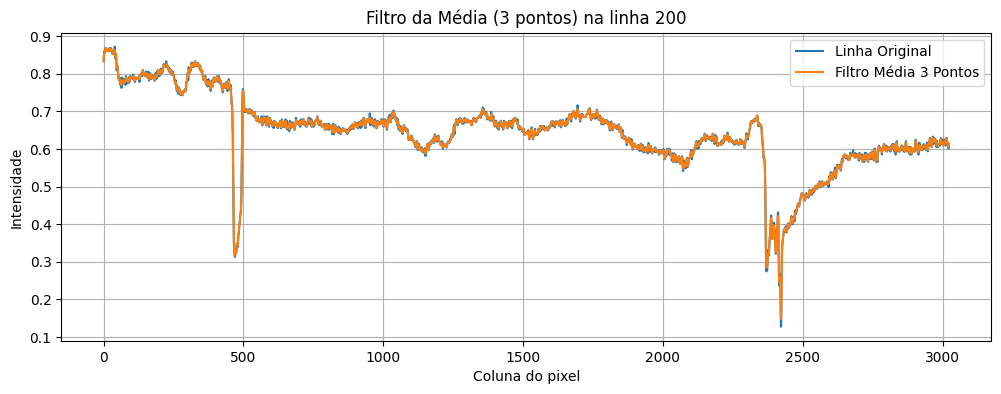

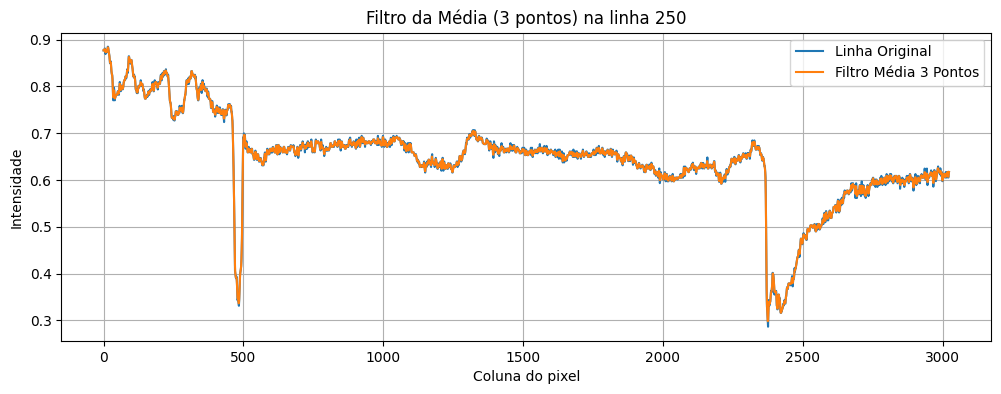

In [7]:
main()


# Exercício: Aplique o filtro de três pontos em todas as linhas da imagem e compare com o resultado da média das imagens da aula anterior.

In [15]:
def gera_ruido(original, noise_type="salt_pepper", noise_level=0.15):
    img = original.copy()
    img = img.astype(float)
    img = (img - img.min()) / (img.max() - img.min())

    if noise_type == "salt_pepper":
        rnd = np.random.rand(*img.shape)
        img[rnd < noise_level/2] = 0      # pimenta
        img[rnd > 1 - noise_level/2] = 1  # sal

    elif noise_type == "gaussian":
        noise = np.random.normal(0, noise_level, img.shape)
        img = img + noise

    return np.clip(img, 0, 1)


In [11]:
# Filtro de média 2D (aula anterior – kernel 3x3)
def filtroMedia2D(imagem):
    filtrada = np.zeros_like(imagem)
    linhas, colunas = imagem.shape

    for i in range(1, linhas-1):
        for j in range(1, colunas-1):
            vizinhanca = imagem[i-1:i+2, j-1:j+2]
            filtrada[i, j] = np.mean(vizinhanca)

    return filtrada

In [12]:
# Filtro de média 1D – kernel 3 pontos (linha)
def filtroMedia3pontos(rowData):
    resultado = np.copy(rowData).astype(float)

    for i in range(1, len(rowData)-1):
        resultado[i] = (rowData[i-1] + rowData[i] + rowData[i+1]) / 3.0

    return resultado

In [13]:
# Aplicar o filtro 1D em todas as linhas da imagem
def aplicaFiltroMedia1D(imagem):
    filtrada = np.zeros_like(imagem, dtype=float)

    for i in range(imagem.shape[0]):
        filtrada[i, :] = filtroMedia3pontos(imagem[i, :])

    return filtrada

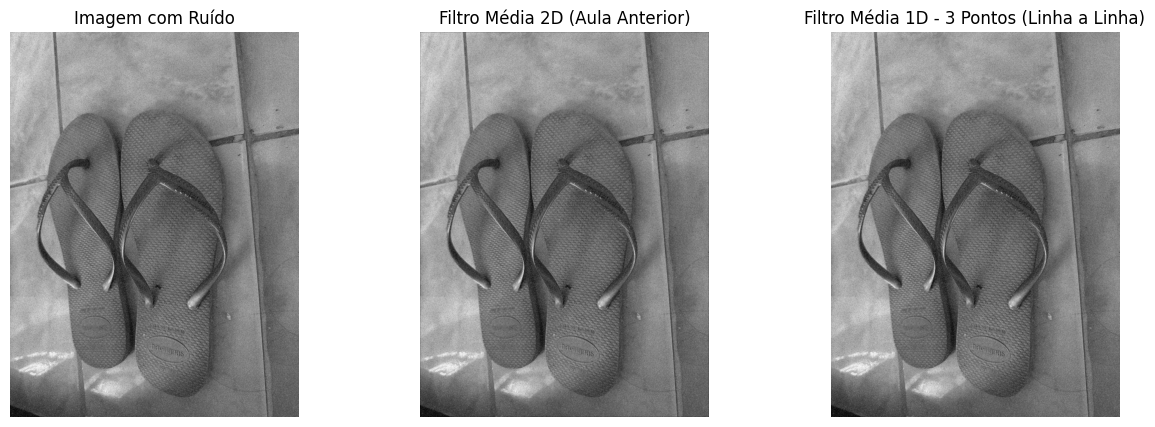

In [16]:
img = imagens[0]
img_ruido = gera_ruido(img)
img_media_2D = filtroMedia2D(img_ruido)
img_media_1D = aplicaFiltroMedia1D(img_ruido)

# Comparação
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_ruido, cmap='gray')
plt.title("Imagem com Ruído")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_media_2D, cmap='gray')
plt.title("Filtro Média 2D (Aula Anterior)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_media_1D, cmap='gray')
plt.title("Filtro Média 1D - 3 Pontos (Linha a Linha)")
plt.axis('off')

plt.show()
